## Import och Databehandling för klimatdata från SMHI
*E. Haaf (Chalmers), 2026*

Detta skript läser flera klimatvariabler direkt från SMHI:s CSV-format och skapar ett gemensamt dagligt dataset med:

1. **Medeltemperatur** (°C) — `smhi-opendata_2_86420.csv`
2. **Min- och maxtemperatur** (°C) — `smhi-opendata_19_20_86420.csv`
3. **Relativ luftfuktighet** (%) — `smhi-opendata_6_86420.csv`, timsdata → dagsmedel
4. **Vindhastighet** (m/s) — `smhi-opendata_3_4_86420.csv`, timsdata → dagsmedel
5. **Solstrålning** (MJ m⁻² d⁻¹) — `smhi-opendata_11_41_42_10_24_86655.csv`, timsvärden i Wh m⁻² × 0.0036 → summeras per dag

Det slutliga datasetet exporteras till `klimatdata.csv` i datamappen.

### 0. Importera bibliotek

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

### 1. Hjälpfunktion för att läsa SMHI CSV-format

In [2]:
def lasa_smhi(filnamn, sep=';'):
    """Läser en SMHI CSV-fil och hoppar över metadata-raderna i början.
    Returnerar en DataFrame med rader från och med header-raden."""
    skip_rows = 0
    with open(filnamn, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if 'Datum' in line or 'Från Datum Tid' in line:  # Hitta header-raden
                skip_rows = i
                break
    return pd.read_csv(filnamn, skiprows=skip_rows, sep=sep)

### 2. Medeltemperatur (dygnsmedeltemperatur)

In [3]:
data_mapp = "../data"  # Sökväg till datamappen

# Läs medeltemperatur (dygnsdata med "Representativt dygn"-kolumn)
raw = lasa_smhi(os.path.join(data_mapp, "smhi-opendata_2_86420.csv"))
raw = raw[['Representativt dygn', 'Lufttemperatur', 'Kvalitet']].copy()

# Behåll G och Y som giltiga kvalitetskoder
raw['Lufttemperatur'] = pd.to_numeric(raw['Lufttemperatur'], errors='coerce')
raw.loc[~raw['Kvalitet'].isin(['G', 'Y']), 'Lufttemperatur'] = float('nan')

# Skapa dygns-DataFrame
temp_medel = raw[['Representativt dygn', 'Lufttemperatur']].copy()
temp_medel.columns = ['Datum', 'Tmean']
temp_medel['Datum'] = pd.to_datetime(temp_medel['Datum'])
temp_medel = temp_medel.set_index('Datum')
print(f"Medeltemperatur: {len(temp_medel)} dagar")
print(temp_medel.head())

Medeltemperatur: 10934 dagar
            Tmean
Datum            
1995-12-17   -1.5
1995-12-18   -4.2
1995-12-19   -7.1
1995-12-20  -10.3
1995-12-21   -8.5


### 3. Min- och maxtemperatur

In [4]:
# Filen innehåller två kolumner med samma namn "Lufttemperatur" (min och max)
# Kolumnordning: 0=Från Datum, 1=Till Datum, 2=Representativt dygn,
#                3=Tmin, 4=Kval_min, 5=Tmax, 6=Kval_max
raw = lasa_smhi(os.path.join(data_mapp, "smhi-opendata_19_20_86420.csv"))
raw = raw.iloc[:, [2, 3, 4, 5, 6]].copy()
raw.columns = ['Datum', 'Tmin', 'Kval_min', 'Tmax', 'Kval_max']

# Numerisk konvertering och kvalitetskontroll
raw['Tmin'] = pd.to_numeric(raw['Tmin'], errors='coerce')
raw['Tmax'] = pd.to_numeric(raw['Tmax'], errors='coerce')
raw.loc[~raw['Kval_min'].isin(['G', 'Y']), 'Tmin'] = float('nan')
raw.loc[~raw['Kval_max'].isin(['G', 'Y']), 'Tmax'] = float('nan')

temp_minmax = raw[['Datum', 'Tmin', 'Tmax']].copy()
temp_minmax['Datum'] = pd.to_datetime(temp_minmax['Datum'])
temp_minmax = temp_minmax.set_index('Datum')
print(f"Min/max-temperatur: {len(temp_minmax)} dagar")
print(temp_minmax.head())

Min/max-temperatur: 10938 dagar
            Tmin  Tmax
Datum                 
1995-12-15  -1.3   1.7
1995-12-16  -3.0   0.1
1995-12-17  -3.1   0.9
1995-12-18  -6.3  -1.4
1995-12-19  -9.7  -5.5


### 4. Relativ luftfuktighet (timsdata → dagsmedel)

In [5]:
# Luftfuktigheten är timsdata med separata Datum- och Tid-kolumner
raw = lasa_smhi(os.path.join(data_mapp, "smhi-opendata_6_86420.csv"))
raw = raw[['Datum', 'Relativ Luftfuktighet', 'Kvalitet']].copy()

# Numerisk konvertering och kvalitetskontroll
raw['Relativ Luftfuktighet'] = pd.to_numeric(raw['Relativ Luftfuktighet'], errors='coerce')
raw.loc[~raw['Kvalitet'].isin(['G', 'Y']), 'Relativ Luftfuktighet'] = float('nan')

# Beräkna dagsmedel genom gruppering på Datum
raw['Datum'] = pd.to_datetime(raw['Datum'])
rh = raw.groupby('Datum')['Relativ Luftfuktighet'].mean().rename('RHmean')
print(f"Relativ luftfuktighet: {len(rh)} dagar")
print(rh.head())

Relativ luftfuktighet: 10880 dagar
Datum
1996-01-01    99.000000
1996-02-01    99.750000
1996-02-02    98.500000
1996-02-03    99.478261
1996-02-04    73.909091
Name: RHmean, dtype: float64


C:\Users\ezra\AppData\Local\Temp\ipykernel_36244\3589478856.py:10: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(filnamn, skiprows=skip_rows, sep=sep)


### 5. Vindhastighet (timsdata → dagsmedel)

In [6]:
# Filen innehåller timsdata med Datum, Tid, Vindriktning och Vindhastighet
# Vi behöver endast Vindhastighet, inte Vindriktning
raw = lasa_smhi(os.path.join(data_mapp, "smhi-opendata_3_4_86420.csv"))
raw = raw[['Datum', 'Vindhastighet', 'Kvalitet.1']].copy()  # Kvalitet.1 hör till Vindhastighet

# Numerisk konvertering och kvalitetskontroll
raw['Vindhastighet'] = pd.to_numeric(raw['Vindhastighet'], errors='coerce')
raw.loc[~raw['Kvalitet.1'].isin(['G', 'Y']), 'Vindhastighet'] = float('nan')

# Beräkna dagsmedel
raw['Datum'] = pd.to_datetime(raw['Datum'])
wind = raw.groupby('Datum')['Vindhastighet'].mean().rename('Windmean')
print(f"Vindhastighet: {len(wind)} dagar")
print(wind.head())

C:\Users\ezra\AppData\Local\Temp\ipykernel_36244\3589478856.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(filnamn, skiprows=skip_rows, sep=sep)


Vindhastighet: 10926 dagar
Datum
1995-12-22    1.5000
1995-12-23    3.0000
1995-12-24    3.0000
1995-12-25    1.7500
1995-12-26    3.3125
Name: Windmean, dtype: float64


### 6. Solstrålning (timsvärden Wh m⁻² → dagssumma MJ m⁻² d⁻¹)

In [7]:
# Filen innehåller timsdata med Global Irradians i W m⁻² (medelvärde per timma)
# Omvandling: Wh m⁻² = W m⁻² × 1 h → MJ m⁻² genom att multiplicera med 0.0036
# Sedan summeras alla timmar per dag till MJ m⁻² d⁻¹
raw = lasa_smhi(os.path.join(data_mapp, "smhi-opendata_11_41_42_10_24_86655.csv"))
raw = raw[['Datum', 'Global Irradians (svenska stationer)', 'Kvalitet']].copy()

# Numerisk konvertering och kvalitetskontroll
raw['Global Irradians (svenska stationer)'] = pd.to_numeric(
    raw['Global Irradians (svenska stationer)'], errors='coerce')
raw.loc[~raw['Kvalitet'].isin(['G', 'Y']), 'Global Irradians (svenska stationer)'] = float('nan')

# Omvandla varje timvärde (W m⁻²) → Wh m⁻² (× 1 h implicit) → MJ m⁻² (× 0.0036)
raw['Rs_h'] = raw['Global Irradians (svenska stationer)'] * 0.0036

# Summera per dag → MJ m⁻² d⁻¹
raw['Datum'] = pd.to_datetime(raw['Datum'])
solar = raw.groupby('Datum')['Rs_h'].sum().rename('Rs')
print(f"Solstrålning: {len(solar)} dagar")
print(solar.head())

Solstrålning: 15674 dagar
Datum
1983-01-01    0.72936
1983-01-02    1.26360
1983-01-03    0.85032
1983-01-04    1.09188
1983-01-05    1.50408
Name: Rs, dtype: float64


C:\Users\ezra\AppData\Local\Temp\ipykernel_36244\3589478856.py:10: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(filnamn, skiprows=skip_rows, sep=sep)


### 7. Sammanfoga alla variabler och exportera

In [8]:
# Sammanfoga alla dagliga tidsserier på Datum-index med yttre join
# (behåller alla datum som förekommer i minst en källa)
klima = (temp_medel
         .join(temp_minmax, how='outer')
         .join(rh, how='outer')
         .join(solar, how='outer')
         .join(wind, how='outer'))

# Sortera kronologiskt
klima = klima.sort_index()

# Skriv ut en sammanfattning
print(f"Slutligt dataset: {len(klima)} dagar, {klima.columns.tolist()}")
print(klima.head(10))

Slutligt dataset: 15676 dagar, ['Tmean', 'Tmin', 'Tmax', 'RHmean', 'Rs', 'Windmean']
            Tmean  Tmin  Tmax  RHmean       Rs  Windmean
Datum                                                   
1983-01-01    NaN   NaN   NaN     NaN  0.72936       NaN
1983-01-02    NaN   NaN   NaN     NaN  1.26360       NaN
1983-01-03    NaN   NaN   NaN     NaN  0.85032       NaN
1983-01-04    NaN   NaN   NaN     NaN  1.09188       NaN
1983-01-05    NaN   NaN   NaN     NaN  1.50408       NaN
1983-01-06    NaN   NaN   NaN     NaN  0.24120       NaN
1983-01-07    NaN   NaN   NaN     NaN  0.82440       NaN
1983-01-08    NaN   NaN   NaN     NaN  1.10736       NaN
1983-01-09    NaN   NaN   NaN     NaN  0.42660       NaN
1983-01-10    NaN   NaN   NaN     NaN  1.67184       NaN


In [9]:
# Exportera till CSV i datamappen
output_path = os.path.join(data_mapp, "klimatdata.csv")
klima.to_csv(output_path)  # index=True för att spara Datum som kolumn
print(f"Klimatdata har sparats till {output_path}")

Klimatdata har sparats till ../data\klimatdata.csv


### 8. Visualisering

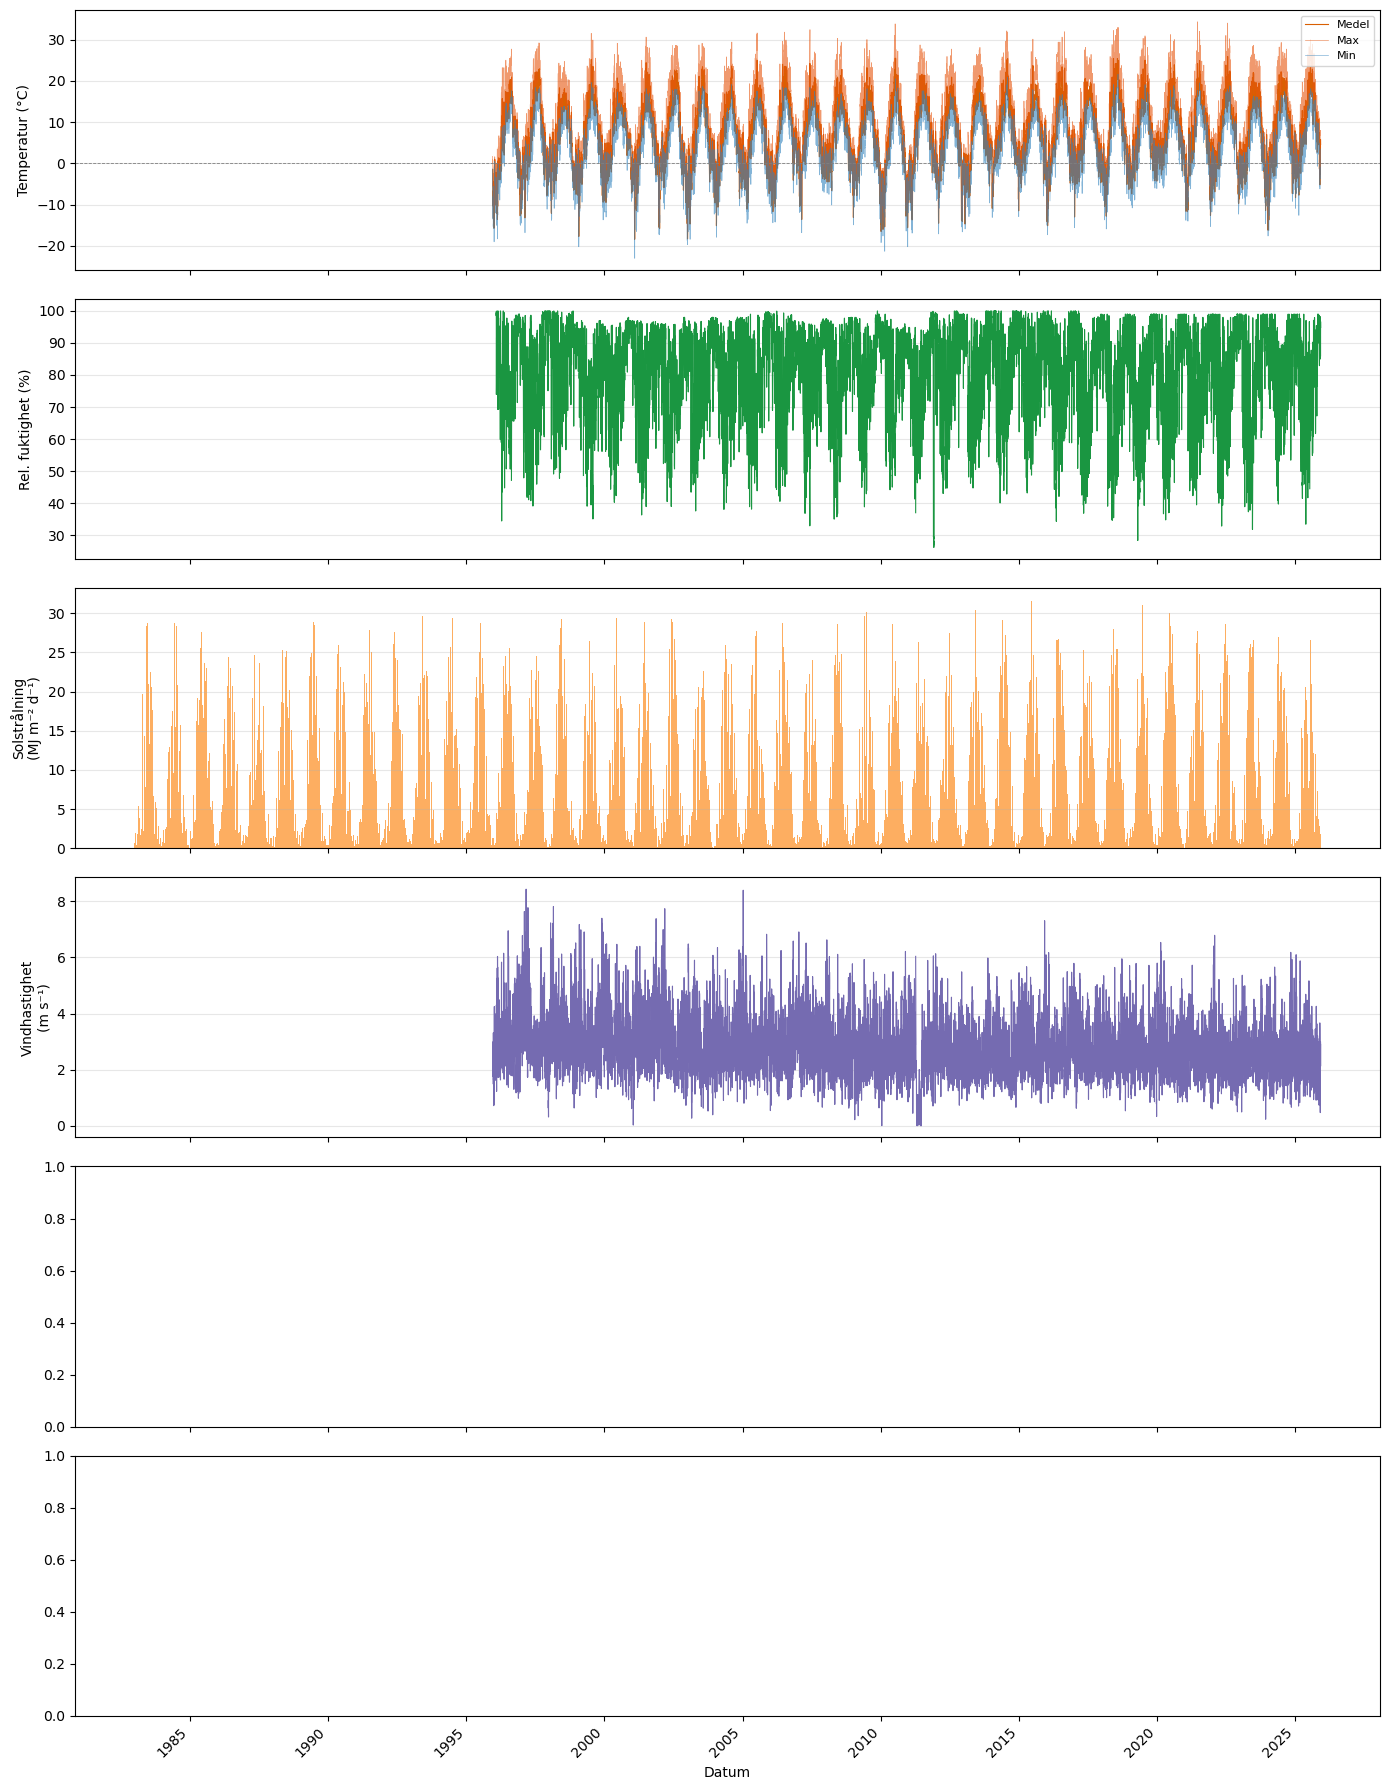

In [10]:
# Översiktsfigur med alla sex variabler i separata delpaneler
fig, axs = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

# Temperatur: medel, min och max i samma panel
axs[0].plot(klima.index, klima['Tmean'], color='#d95f02', linewidth=0.8, label='Medel')
axs[0].plot(klima.index, klima['Tmax'],  color='#e6550d', linewidth=0.5, alpha=0.6, label='Max')
axs[0].plot(klima.index, klima['Tmin'],  color='#3182bd', linewidth=0.5, alpha=0.6, label='Min')
axs[0].axhline(0, color='gray', linewidth=0.6, linestyle='--')
axs[0].set_ylabel('Temperatur (°C)')
axs[0].legend(fontsize=8, loc='upper right')
axs[0].grid(axis='y', alpha=0.3)

# Relativ luftfuktighet
axs[1].plot(klima.index, klima['RHmean'], color='#1a9641', linewidth=0.8)
axs[1].set_ylabel('Rel. fuktighet (%)')
axs[1].grid(axis='y', alpha=0.3)

# Solstrålning
axs[2].bar(klima.index, klima['Rs'], width=1.0, color='#fdae61', label='Rs')
axs[2].set_ylabel('Solstrålning\n(MJ m⁻² d⁻¹)')
axs[2].grid(axis='y', alpha=0.3)

# Vindhastighet
axs[3].plot(klima.index, klima['Windmean'], color='#756bb1', linewidth=0.8)
axs[3].set_ylabel('Vindhastighet\n(m s⁻¹)')
axs[3].grid(axis='y', alpha=0.3)

plt.xlabel('Datum')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show(block=False)
plt.close(fig)